In [2]:
from pathlib import Path
import pickle
import itertools
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Colors:

In [ ]:
# PAIRED_10_HEX = [
#     "#a6cee3",  # 0  light blue
#     "#1f78b4",  # 1  dark blue
#     "#b2df8a",  # 2  light green
#     "#33a02c",  # 3  dark green
#     "#fb9a99",  # 4  light red
#     "#e31a1c",  # 5  dark red
#     "#fdbf6f",  # 6  light orange
#     "#ff7f00",  # 7  dark orange
#     "#cab2d6",  # 8  light purple
#     "#6a3d9a",  # 9  dark purple
# ]

In [ ]:
PAIRED_10 = sns.color_palette("Paired", n_colors=10)
PAIRED_10_HEX = [
    "#{:02x}{:02x}{:02x}".format(int(r * 255), int(g * 255), int(b * 255))
    for r, g, b in PAIRED_10
]

print("PAIRED_10_HEX =")
print(PAIRED_10_HEX)

fig, ax = plt.subplots(figsize=(12, 1.4))
for i, (rgb, hexc) in enumerate(zip(PAIRED_10, PAIRED_10_HEX)):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=rgb))
    ax.text(i + 0.5, -0.18, hexc, ha="center", va="top", fontsize=8, family="monospace")
    ax.text(i + 0.5, 0.5, str(i), ha="center", va="center", fontsize=11, color="black" if i % 2 == 0 else "white")
ax.set_xlim(0, 10)
ax.set_ylim(-0.45, 1)
ax.set_axis_off()
ax.set_title("Paired · 10 colors", pad=8)
plt.tight_layout()
plt.show()


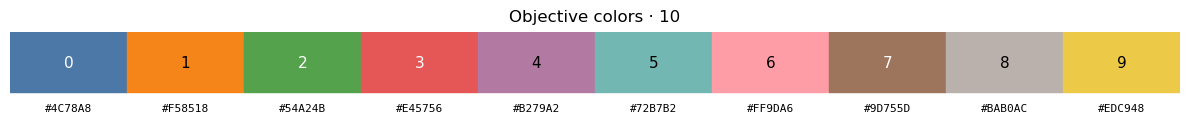

In [13]:
OBJ_COLORS = [
    "#4C78A8",   # blue
    "#F58518",   # orange
    "#54A24B",   # green
    "#E45756",   # red
    "#B279A2",   # purple

    # Additional colors
    "#72B7B2",   # teal
    "#FF9DA6",   # pink
    "#9D755D",   # brown
    "#BAB0AC",   # warm gray
    "#EDC948",   # yellow
]
fig, ax = plt.subplots(figsize=(12, 1.4))
for i, hexc in enumerate(OBJ_COLORS):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=hexc))
    ax.text(i + 0.5, -0.18, hexc, ha="center", va="top", fontsize=8, family="monospace")
    r, g, b = int(hexc[1:3], 16), int(hexc[3:5], 16), int(hexc[5:7], 16)
    label_color = "black" if (0.299 * r + 0.587 * g + 0.114 * b) > 140 else "white"
    ax.text(i + 0.5, 0.5, f"{i}", ha="center", va="center", fontsize=11, color=label_color)
ax.set_xlim(0, 10)
ax.set_ylim(-0.45, 1)
ax.set_axis_off()
ax.set_title("Objective colors · 10", pad=8)
plt.tight_layout()
plt.show()

In [ ]:
LINE_COLORS_20 = [
    "#4C78A8",  # blue
    "#F58518",  # orange
    "#54A24B",  # green
    "#B279A2",  # purple
    "#E45756",  # red
    "#72B7B2",  # teal
    "#9D755D",  # brown
    "#8172A0",  # muted violet
    "#7A9561",  # sage
    "#C78591",  # dusty rose
    "#61788A",  # slate
    "#C07A52",  # rust
    "#5F9290",  # dark teal
    "#A86464",  # brick
    "#B49A52",  # ochre
    "#7F8588",  # cool gray
    "#FF9DA6",  # pink
    "#806A58",  # taupe
    "#EDC948",  # yellow
    "#BAB0AC",  # warm gray
]

Unbiased vs biased pf:

In [10]:
original_sub_id = 4
trial_id = 1
submission_number = 1    

unbiased_pf = pd.read_csv(f"data/game_data/pf_block_2_trial_{trial_id}_2005.csv").to_numpy()
biased_pf = pd.read_csv(f"data/results/sub_{original_sub_id}/block_2/trial_{trial_id}/submission_{submission_number}/pf.csv").to_numpy()

with open(f"data/sub_data/sub_{original_sub_id}/sub_{original_sub_id}_block_2_trial_{trial_id}.json") as file:
    data = json.load(file)
    
df = pd.json_normalize(
    data,
    record_path="submissions",
    meta=["trial_id", "submission_count", "sub_id", "block_id", "trial_type"],
)
info = pd.DataFrame({
    "trial_id": df["trial_id"],
    "submission_number": df["submission_number"],
    "slider_values": df["slider_values"],
    "server_result.rec": df["server_result.rec"]
})

aspi = np.asarray(info.loc[submission_number - 1, "slider_values"])
query_pt = np.asarray(info.loc[submission_number - 1, "server_result.rec"])

In [11]:
# density filter
from mrs import _safe_iqr, density_filter

unbiased_pf_filtered, _ = density_filter(unbiased_pf, 0.8)
biased_pf_filtered = biased_pf

In [ ]:
import math

n_obj = 5
# df = pd.read_csv("data/game_data/pf_block_2_trial_1_2005.csv")
# objective_names = df.columns.tolist()
objective_names = ["obj0", "obj1", "obj2", "obj3", "obj4"]

objective_pairs = list(itertools.combinations(range(n_obj), 2))
n_plots = len(objective_pairs)
cols = min(5, n_plots)
rows = math.ceil(n_plots / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
axes = np.atleast_1d(axes).ravel()
for ax, (a, b) in zip(axes, objective_pairs):
    ax.plot(unbiased_pf[:, a], unbiased_pf[:, b], "go", alpha=0.2, markersize=3, label="PF")
    ax.plot(biased_pf[:, a], biased_pf[:, b], "bo", alpha=0.2, markersize=3, label="PF")
    # sns.kdeplot(
    #     x=pf_actual_norm[:, a],
    #     y=pf_actual_norm[:, b],
    #     levels=10,
    #     fill=True,   
    #     color="green",
    #     ax=ax
    # )
    # sns.kdeplot(
    #     x=pf_norm[:, a],
    #     y=pf_norm[:, b],
    #     levels=10,
    #     fill=True,   
    #     color="steelblue",
    #     alpha=0.4,
    #     ax=ax
    # )
    ax.plot(
        aspi[a], aspi[b],
        "rs", alpha=1, markersize=6, label="Aspiration"
    )
    ax.plot(
        query_pt[a], query_pt[b],
        "ks", alpha=1, markersize=6, label="Query"
    )
    ax.set_xlabel(objective_names[a])
    ax.set_ylabel(objective_names[b])
    # ax.set_xlim(40, 140)
    # ax.set_ylim(40, 140)

for ax in axes[n_plots:]:
    ax.set_visible(False)

fig.tight_layout()
plt.show()

In [ ]:
from matplotlib.gridspec import GridSpec

df = pd.read_csv("data/game_data/pf_block_2_trial_1_2005.csv")
objective_names = df.columns.tolist()

fig = plt.figure(figsize=(11, 6))
gs = GridSpec(2, 2, figure=fig, width_ratios=[2, 1], height_ratios=[1, 1])

ax1 = fig.add_subplot(gs[:, 0])   # left: full height
ax2 = fig.add_subplot(gs[0, 1])   # top-right: half height
ax3 = fig.add_subplot(gs[1, 1])   # bottom-right: half height

ax1.scatter(unbiased_pf_filtered[:, 1], unbiased_pf_filtered[:, 3], color=OBJ_COLORS[0], alpha=0.5, s=10, label="PF")
ax1.scatter(biased_pf_filtered[:, 1], biased_pf_filtered[:, 3], color=OBJ_COLORS[1], alpha=0.5, s=10, label="PF")
ax1.scatter(aspi[1], aspi[3], color="#54A24B", alpha=1, s=30, marker="*", label="Aspiration")
ax1.set_title("Negatively correlated objectives")
ax1.set_xlabel(objective_names[1])
ax1.set_ylabel(objective_names[3])
# ax1.set_xlim(12, 65)
# ax1.set_ylim(0, 25)

ax2.scatter(unbiased_pf_filtered[:, 0], unbiased_pf_filtered[:, 3], color=OBJ_COLORS[0], alpha=0.3, s=4, label="PF")
ax2.scatter(biased_pf_filtered[:, 0], biased_pf_filtered[:, 3], color=OBJ_COLORS[1], alpha=0.3, s=4, label="PF")
ax2.scatter(aspi[0], aspi[3], color="#54A24B", alpha=1, s=23, marker="*", label="Aspiration")
ax2.set_xlabel(objective_names[0])
ax2.set_ylabel(objective_names[3])
ax2.set_title("Positively correlated objectives")
# ax2.set_xlim(0, 1)
# ax2.set_ylim(0, 1)

ax3.scatter(unbiased_pf_filtered[:, 2], unbiased_pf_filtered[:, 4], color=OBJ_COLORS[0], alpha=0.3, s=4, label="PF")
ax3.scatter(biased_pf_filtered[:, 2], biased_pf_filtered[:, 4], color=OBJ_COLORS[1], alpha=0.3, s=4, label="PF")
ax3.scatter(aspi[2], aspi[4], color="#54A24B", alpha=1, s=23, marker="*", label="Aspiration")
ax3.set_xlabel(objective_names[2])
ax3.set_ylabel(objective_names[4])
ax3.set_title("Uncorrelated objectives")
# ax3.set_xlim(0, 1)
# ax3.set_ylim(0, 1)

for ax in (ax1, ax2, ax3):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig("pf_compare.png", dpi=300, bbox_inches="tight")

In [ ]:
df = pd.read_csv("data/game_data/pf_block_2_trial_1_2005.csv")
objective_names = df.columns.tolist()
CONDITION_COLORS = [
    "#4C78A8",  # muted blue
    "#A9A9A9",  # gray
]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(11, 3))

ax1.scatter(unbiased_pf_filtered[:, 1], unbiased_pf_filtered[:, 3], color=CONDITION_COLORS[1], alpha=0.3, s=4, label="PF")
ax1.scatter(biased_pf_filtered[:, 1], biased_pf_filtered[:, 3], color=CONDITION_COLORS[0], alpha=0.3, s=4, label="PF")
ax1.scatter(aspi[1], aspi[3], color="#F58518", alpha=1, s=30, marker="*", label="Aspiration")
ax1.set_title("Negatively correlated objectives")
ax1.set_xlabel(objective_names[1])
ax1.set_ylabel(objective_names[3])

ax2.scatter(unbiased_pf_filtered[:, 0], unbiased_pf_filtered[:, 3], color=CONDITION_COLORS[1], alpha=0.3, s=4, label="PF")
ax2.scatter(biased_pf_filtered[:, 0], biased_pf_filtered[:, 3], color=CONDITION_COLORS[0], alpha=0.3, s=4, label="PF")
ax2.scatter(aspi[0], aspi[3], color="#F58518", alpha=1, s=30, marker="*", label="Aspiration")
ax2.set_xlabel(objective_names[0])
ax2.set_ylabel(objective_names[3])
ax2.set_title("Positively correlated objectives")

ax3.scatter(unbiased_pf_filtered[:, 2], unbiased_pf_filtered[:, 4], color=CONDITION_COLORS[1], alpha=0.3, s=4, label="PF")
ax3.scatter(biased_pf_filtered[:, 2], biased_pf_filtered[:, 4], color=CONDITION_COLORS[0], alpha=0.3, s=4, label="PF")
ax3.scatter(aspi[2], aspi[4], color="#F58518", alpha=1, s=30, marker="*", label="Aspiration")
ax3.set_xlabel(objective_names[2])
ax3.set_ylabel(objective_names[4])
ax3.set_title("Uncorrelated objectives")

for ax in (ax1, ax2, ax3):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig("pf_compare_row.png", dpi=300, bbox_inches="tight")


Distance to aspiration distributions

In [14]:
import ast

num_trials = 17
converters = {
    "initial_slider_values": ast.literal_eval,
    "slider_values": ast.literal_eval,
    "rec_values": ast.literal_eval,
}
all_info_nonshifted = pd.read_csv("data/all_info_10_nonshifted.csv", converters=converters)

subject_mapping = (
    all_info_nonshifted[["sub_id", "original_sub_id"]]
    .drop_duplicates()
    .sort_values("sub_id")
)
print(subject_mapping)

     sub_id  original_sub_id
0         0                2
84        1                3
121       2                4
173       3                5
236       4                6
300       5                8
369       6                9
447       7               10
517       8               11
572       9               12


In [ ]:
fig, ax = plt.subplots(figsize=(11, 2.5))

for i, row in enumerate(subject_mapping.itertuples(index=False)):
    sub_id = int(row.sub_id)
    original_sub_id = int(row.original_sub_id)

    distances_unbiased = []
    distances_biased = []

    for trial_id in range(1, num_trials + 1):
        trial_rows = all_info_nonshifted.loc[
            (all_info_nonshifted["sub_id"] == sub_id)
            & (all_info_nonshifted["trial_id"] == trial_id)
        ]
        if trial_rows.empty:
            continue

        last_submission = int(trial_rows["submission_number"].max())
        unbiased_files = list(
            Path("data/game_data").glob(
                f"pf_block_2_trial_{trial_id}_*.csv"
            )
        )
        if len(unbiased_files) != 1:
            raise ValueError(
                f"Trial {trial_id}: expected one unbiased PF, "
                f"found {len(unbiased_files)}"
            )
        unbiased_pf = pd.read_csv(unbiased_files[0]).to_numpy()
        unbiased_pf, _ = density_filter(unbiased_pf, 0.8)

        biased_path = Path(
            f"data/results/sub_{original_sub_id}/block_2/"
            f"trial_{trial_id}/submission_{last_submission}/pf.csv"
        )
        biased_pf = pd.read_csv(biased_path).to_numpy()

        aspiration = np.asarray(
            trial_rows.loc[
                trial_rows["submission_number"] == last_submission,
                "slider_values",
            ].iloc[0],
            dtype=float,
        )

        distances_unbiased.append(
            np.linalg.norm(unbiased_pf - aspiration, axis=1)
        )
        distances_biased.append(
            np.linalg.norm(biased_pf - aspiration, axis=1)
        )

    distances_unbiased = np.concatenate(distances_unbiased)
    distances_biased = np.concatenate(distances_biased)

    sns.kdeplot(
        distances_unbiased,
        ax=ax,
        fill=False,
        color=CONDITION_COLORS[1],
        linewidth=1,
        label="Unbiased Pareto front" if i == 0 else None,
    )
    sns.kdeplot(
        distances_biased,
        ax=ax,
        fill=False,
        color=CONDITION_COLORS[0],
        # linestyle="--",
        linewidth=1,
        label="Human-biased Pareto front" if i == 0 else None,
    )
    # ax.set_ylim(0, 0.077)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(-5, 120)

    ax.set_xlabel("Distance to aspiration")
    ax.set_ylabel("Density")
    ax.legend(frameon=False)

plt.tight_layout()
fig.savefig("dist.png", dpi=300, bbox_inches="tight")

/tmp/ipykernel_1290214/3846502965.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


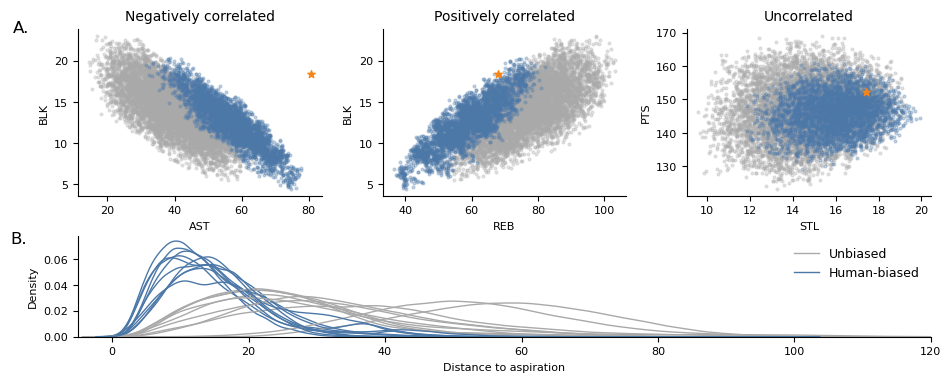

In [15]:
## final figure 1

from matplotlib.gridspec import GridSpec
df = pd.read_csv("data/game_data/pf_block_2_trial_1_2005.csv")
objective_names = df.columns.tolist()
CONDITION_COLORS = [
    "#4C78A8",  # muted blue
    "#A9A9A9",  # gray
]
plt.rcParams.update({
    "axes.titlesize": 10,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 9,
})
fig = plt.figure(figsize=(11, 2.5 + 1.5))
gs = GridSpec(2, 1, figure=fig, height_ratios=[2.5, 1.5], hspace=0.3)
gs_top = gs[0].subgridspec(1, 3, wspace=0.25)
ax1 = fig.add_subplot(gs_top[0, 0])
ax2 = fig.add_subplot(gs_top[0, 1])
ax3 = fig.add_subplot(gs_top[0, 2])
ax_dist = fig.add_subplot(gs[1])

# --- top row: PF scatter ---
ax1.scatter(unbiased_pf_filtered[:, 1], unbiased_pf_filtered[:, 3], color=CONDITION_COLORS[1], alpha=0.3, s=4, label="PF")
ax1.scatter(biased_pf_filtered[:, 1], biased_pf_filtered[:, 3], color=CONDITION_COLORS[0], alpha=0.3, s=4, label="PF")
ax1.scatter(aspi[1], aspi[3], color="#F58518", alpha=1, s=30, marker="*", label="Aspiration")
ax1.set_title("Negatively correlated")
ax1.set_xlabel(objective_names[1])
ax1.set_ylabel(objective_names[3])
ax1.text(
    -0.27, 1.05, "A.",
    transform=ax1.transAxes,
    fontsize=12,
    va="top"
)
ax2.scatter(unbiased_pf_filtered[:, 0], unbiased_pf_filtered[:, 3], color=CONDITION_COLORS[1], alpha=0.3, s=4, label="PF")
ax2.scatter(biased_pf_filtered[:, 0], biased_pf_filtered[:, 3], color=CONDITION_COLORS[0], alpha=0.3, s=4, label="PF")
ax2.scatter(aspi[0], aspi[3], color="#F58518", alpha=1, s=30, marker="*", label="Aspiration")
ax2.set_xlabel(objective_names[0])
ax2.set_ylabel(objective_names[3])
ax2.set_title("Positively correlated")
ax3.scatter(unbiased_pf_filtered[:, 2], unbiased_pf_filtered[:, 4], color=CONDITION_COLORS[1], alpha=0.3, s=4, label="PF")
ax3.scatter(biased_pf_filtered[:, 2], biased_pf_filtered[:, 4], color=CONDITION_COLORS[0], alpha=0.3, s=4, label="PF")
ax3.scatter(aspi[2], aspi[4], color="#F58518", alpha=1, s=30, marker="*", label="Aspiration")
ax3.set_xlabel(objective_names[2])
ax3.set_ylabel(objective_names[4])
ax3.set_title("Uncorrelated")
for ax in (ax1, ax2, ax3):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
# --- bottom row: distance KDEs ---
for i, row in enumerate(subject_mapping.itertuples(index=False)):
    sub_id = int(row.sub_id)
    original_sub_id = int(row.original_sub_id)
    distances_unbiased = []
    distances_biased = []
    for trial_id in range(1, num_trials + 1):
        trial_rows = all_info_nonshifted.loc[
            (all_info_nonshifted["sub_id"] == sub_id)
            & (all_info_nonshifted["trial_id"] == trial_id)
        ]
        if trial_rows.empty:
            continue
        last_submission = int(trial_rows["submission_number"].max())
        unbiased_files = list(
            Path("data/game_data").glob(
                f"pf_block_2_trial_{trial_id}_*.csv"
            )
        )
        if len(unbiased_files) != 1:
            raise ValueError(
                f"Trial {trial_id}: expected one unbiased PF, "
                f"found {len(unbiased_files)}"
            )
        unbiased_pf = pd.read_csv(unbiased_files[0]).to_numpy()
        unbiased_pf, _ = density_filter(unbiased_pf, 0.8)
        biased_path = Path(
            f"data/results/sub_{original_sub_id}/block_2/"
            f"trial_{trial_id}/submission_{last_submission}/pf.csv"
        )
        biased_pf = pd.read_csv(biased_path).to_numpy()
        aspiration = np.asarray(
            trial_rows.loc[
                trial_rows["submission_number"] == last_submission,
                "slider_values",
            ].iloc[0],
            dtype=float,
        )
        distances_unbiased.append(
            np.linalg.norm(unbiased_pf - aspiration, axis=1)
        )
        distances_biased.append(
            np.linalg.norm(biased_pf - aspiration, axis=1)
        )
    distances_unbiased = np.concatenate(distances_unbiased)
    distances_biased = np.concatenate(distances_biased)
    sns.kdeplot(
        distances_unbiased,
        ax=ax_dist,
        fill=False,
        color=CONDITION_COLORS[1],
        linewidth=1,
        label="Unbiased" if i == 0 else None,
    )
    sns.kdeplot(
        distances_biased,
        ax=ax_dist,
        fill=False,
        color=CONDITION_COLORS[0],
        linewidth=1,
        label="Human-biased" if i == 0 else None,
    )
ax_dist.spines["top"].set_visible(False)
ax_dist.spines["right"].set_visible(False)
ax_dist.set_xlim(-5, 120)
ax_dist.set_xlabel("Distance to aspiration")
ax_dist.set_ylabel("Density")
ax_dist.legend(frameon=False, loc="upper right")
ax_dist.text(
    -0.08, 1.05, "B.",
    transform=ax_dist.transAxes,
    fontsize=12,
    va="top"
)
plt.tight_layout()
fig.savefig("figure_pf.png", dpi=300, bbox_inches="tight")

Score (last submission per trial) and diff (averaged over all submissions per trial):

In [ ]:
import ast

converters = {
    "initial_slider_values": ast.literal_eval,
    "slider_values": ast.literal_eval,
    "rec_values": ast.literal_eval,
}
all_info_nonshifted = pd.read_csv("data/all_info_10_nonshifted.csv", converters=converters)

subject_mapping = (
    all_info_nonshifted[["sub_id", "original_sub_id"]]
    .drop_duplicates()
    .sort_values("sub_id")
)

num_subjects = 10
num_trials = 17
trial_numbers = np.arange(1, num_trials + 1)
max_submissions = 5

scores = np.full((num_subjects, num_trials), np.nan)
diffs = np.full((num_subjects, num_trials), np.nan)
slopes_score = np.full(num_subjects, np.nan)
slopes_diff = np.full(num_subjects, np.nan)
fitted_scores = np.full((num_subjects, num_trials), np.nan)
fitted_diffs = np.full((num_subjects, num_trials), np.nan)

for i, row in enumerate(subject_mapping.itertuples(index=False)):
    sub_id = int(row.sub_id)
    original_sub_id = int(row.original_sub_id)

    for trial_id in range(1, num_trials + 1):
        with open(f"data/sub_data/sub_{original_sub_id}/sub_{original_sub_id}_block_2_trial_{trial_id}.json") as file:
            data = json.load(file)

        df = pd.json_normalize(
            data,
            record_path="submissions",
            meta=["trial_id", "submission_count", "sub_id", "block_id", "trial_type"],
        )

        scores[sub_id - 1, trial_id - 1] = df["server_result.score"].iloc[-1]

        slider_values_frac = np.asarray([
            np.asarray(values) / np.asarray(maxs)
            for values, maxs in zip(df["slider_values"], df["slider_maxs"])
        ])
        rec_values_frac = np.asarray([
            np.asarray(values) / np.asarray(maxs)
            for values, maxs in zip(df["server_result.rec"], df["slider_maxs"])
        ])
        diff_values_frac = np.round(slider_values_frac - rec_values_frac, 2)
        diffs[sub_id - 1, trial_id - 1] = np.abs(diff_values_frac).sum()

    slope_score, intercept_score = np.polyfit(
        trial_numbers, scores[sub_id - 1], 1
    )
    log_diffs = np.log(diffs[sub_id - 1])
    slope_diff, intercept_diff = np.polyfit(
        trial_numbers, log_diffs, 1
    )
    fitted_scores[sub_id - 1] = slope_score * trial_numbers + intercept_score
    fitted_diffs[sub_id - 1] = np.exp(slope_diff * trial_numbers + intercept_diff)
    slopes_score[sub_id - 1] = slope_score
    slopes_diff[sub_id - 1] = slope_diff

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(6, 6))
subject_ids = np.arange(num_subjects)

axes[1].barh(
    subject_ids,
    slopes_score,
    color=PAIRED_10_HEX[8],
    width=0.5,
    edgecolor=PAIRED_10_HEX[8],
    linewidth=1.5,
)
axes[1].axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)
axes[1].set(
    xlabel="Slope of score vs. trial",
)
axes[1].set_yticks([])

axes[0].barh(
    subject_ids,
    slopes_diff,
    color=PAIRED_10_HEX[2],
    width=0.5,
    edgecolor=PAIRED_10_HEX[2],
    linewidth=1.5,
)
axes[0].axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)
axes[0].set(
    ylabel="Subjects",
    xlabel="Slope of log difference between \ndesired and recommended solutions vs. trial",
)
axes[0].set_yticks(subject_ids)
axes[0].set_yticklabels(np.arange(1, num_subjects + 1))

plt.tight_layout()
fig.savefig("score_diff.png", dpi=300, bbox_inches="tight")

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(4, 4))
subject_ids = np.arange(num_subjects)
subject_labels = np.arange(1, num_subjects + 1)

axes[0].bar(
    subject_ids,
    slopes_score,
    width=0.6,
    color=OBJ_COLORS[2],
    edgecolor=OBJ_COLORS[2],
    linewidth=1.5,
)
axes[0].axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)
axes[0].set(
    ylabel="Slope of score vs. trial",
)
axes[0].tick_params(axis="x", bottom=False, labelbottom=False)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

axes[1].bar(
    subject_ids,
    slopes_diff,
    width=0.6,
    color=OBJ_COLORS[4],
    edgecolor=OBJ_COLORS[4],
    linewidth=1.5,
)
axes[1].axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)
axes[1].set(
    xlabel="Subjects",
    ylabel="Slope of log distance\nbetween desired and recommended\nsolutions vs. trial",
)
axes[1].set_xticks(subject_ids)
axes[1].set_xticklabels(np.arange(1, num_subjects + 1))
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig("score_diff_col.png", dpi=300, bbox_inches="tight")


Tradeoff question:

In [ ]:
from itertools import combinations

corrs_by_year = {}
for year in range(2000, 2017):
    items_df = pd.read_csv(f"data/items/items_{year}.csv").drop(columns=["PLAYER", "SALARY"])
    objective_names = items_df.columns.to_numpy()
    corrs = items_df.corr().to_numpy()
    
    pair_corrs = {
        (objective_names[i], objective_names[j]): corrs[i, j]
        for i, j in combinations(range(len(objective_names)), 2)
    }
    corrs_by_year[year] = dict(
        sorted(pair_corrs.items(), key=lambda pair: pair[1], reverse=True)
    )
    print(corrs_by_year[year])

In [ ]:
corrs_by_year[2000]

In [ ]:
labels = [", ".join(key) if isinstance(key, tuple) else str(key)
          for key in corrs_by_year[2000].keys()]
labels

In [ ]:
converters = {
    "initial_slider_values": ast.literal_eval,
    "slider_values": ast.literal_eval,
    "rec_values": ast.literal_eval,
}
all_info_nonshifted = pd.read_csv("data/all_info_10_nonshifted.csv", converters=converters)

subject_mapping = (
    all_info_nonshifted[["sub_id", "original_sub_id"]]
    .drop_duplicates()
    .sort_values("sub_id")
)

df = pd.read_csv("data/game_data/pf_block_2_trial_1_2005.csv")
objective_names = df.columns.tolist()
objective_order = {name: i for i, name in enumerate(objective_names)}
def tradeoff_key(values):
    return tuple(sorted(values, key=objective_order.get))

num_subjects = 10
num_trials = 17
trial_numbers = np.arange(1, num_trials + 1)

small_ranks = []
large_ranks = []
for i, row in enumerate(subject_mapping.itertuples(index=False)):
    sub_id = int(row.sub_id)
    original_sub_id = int(row.original_sub_id)

    with open(f"data/sub_data/sub_{original_sub_id}/sub_{original_sub_id}_block_2_query.json") as file:
        data = json.load(file)

    df = pd.json_normalize(data)
    small_tradeoff_key = tradeoff_key(df["largest_tradeoff_1"][0])
    large_tradeoff_key = tradeoff_key(df["largest_tradeoff_2"][0])

    keys = list(corrs_by_year[2000].keys())
    small_index = keys.index(small_tradeoff_key)
    large_index = keys.index(large_tradeoff_key)

    small_ranks.append(small_index)
    large_ranks.append(large_index)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 6))
subject_ids = np.arange(num_subjects)
x = np.arange(num_subjects)
width = 0.35

ax.barh(
    x - width / 2,
    small_ranks,
    color=PAIRED_10_HEX[0],
    height=width,
    edgecolor=PAIRED_10_HEX[0],
    linewidth=1.5,
    label="Smallest tradeoff"
)
ax.barh(
    x + width / 2,
    large_ranks,
    color=PAIRED_10_HEX[1],
    height=width,
    edgecolor=PAIRED_10_HEX[1],
    linewidth=1.5,
    label="Largest tradeoff",
)
ax.set_yticks(x)
ax.set_yticklabels(np.arange(1, num_subjects + 1))  # or subject labels
ax.set_ylabel("Subjects")
ax.set_xticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_xlabel("Objective pairs sorted by decreasing tradeoff")
ax.legend()

plt.tight_layout()
fig.savefig("tradeoff.png", dpi=300, bbox_inches="tight")

In [ ]:
converters = {
    "initial_slider_values": ast.literal_eval,
    "slider_values": ast.literal_eval,
    "rec_values": ast.literal_eval,
}
all_info_nonshifted = pd.read_csv("data/all_info_10_nonshifted.csv", converters=converters)

subject_mapping = (
    all_info_nonshifted[["sub_id", "original_sub_id"]]
    .drop_duplicates()
    .sort_values("sub_id")
)

df = pd.read_csv("data/game_data/pf_block_2_trial_1_2005.csv")
objective_names = df.columns.tolist()
objective_order = {name: i for i, name in enumerate(objective_names)}
def tradeoff_key(values):
    return tuple(sorted(values, key=objective_order.get))

objective_pairs = {
    (objective_names[i], objective_names[j]): (i, j)
    for i, j in itertools.combinations(range(len(objective_names)), 2)
}
pair_keys = list(objective_pairs)
labels = [", ".join(pair) for pair in pair_keys]

num_subjects = 10
num_trials = 17
trial_numbers = np.arange(1, num_trials + 1)

small_ranks = []
large_ranks = []
for i, row in enumerate(subject_mapping.itertuples(index=False)):
    sub_id = int(row.sub_id)
    original_sub_id = int(row.original_sub_id)

    with open(f"data/sub_data/sub_{original_sub_id}/sub_{original_sub_id}_block_2_query.json") as file:
        data = json.load(file)

    df = pd.json_normalize(data)
    small_tradeoff_key = tradeoff_key(df["largest_tradeoff_1"][0])
    large_tradeoff_key = tradeoff_key(df["largest_tradeoff_2"][0])
    print(small_tradeoff_key, large_tradeoff_key)

    small_index = objective_pairs[small_tradeoff_key]
    large_index = objective_pairs[large_tradeoff_key]

    small_ranks.append(small_index)
    large_ranks.append(large_index)

In [ ]:
n_obj = 5
tradeoff_response = np.zeros((n_obj, n_obj))
for small_index, large_index in zip(small_ranks, large_ranks):
    small_1, small_2 = small_index
    large_1, large_2 = large_index
    tradeoff_response[small_1, small_2] += 1
    tradeoff_response[small_2, small_1] += 1
    tradeoff_response[large_1, large_2] -= 1
    tradeoff_response[large_2, large_1] -= 1
tradeoff_response

In [ ]:
# sns.heatmap(tradeoff_response, annot=True, cmap="RdBu_r")
mask = np.triu(np.ones_like(tradeoff_response, dtype=bool))
sns.heatmap(tradeoff_response, annot=True, cmap="RdBu_r", mask=mask, xticklabels=objective_names, yticklabels=objective_names,
    vmin=-5,
    vmax=5,
    center=0,
)
plt.show()

In [ ]:
corrs_list = []
for trial_id in range(1, num_trials + 1):
    unbiased_files = list(Path("data/game_data").glob(f"pf_block_2_trial_{trial_id}_????.csv"))
    if len(unbiased_files) != 1:
        raise FileNotFoundError(
            f"Expected one file for trial {trial_id}, found {len(unbiased_files)}: {unbiased_files}"
        )
    unbiased_pf = pd.read_csv(unbiased_files[0])
    if trial_id == 1:
        objective_names = unbiased_pf.columns.tolist()
    # Columns are objectives; rows are Pareto points.
    corrs_list.append(unbiased_pf.corr(method="spearman").to_numpy())

corrs_list = np.stack(corrs_list)  # (n_trials, n_obj, n_obj)
mean_corrs = np.nanmean(corrs_list, axis=0)
mask = np.triu(np.ones_like(mean_corrs, dtype=bool))
sns.heatmap(mean_corrs, annot=True, cmap="RdBu_r", mask=mask, 
    xticklabels=objective_names, yticklabels=objective_names,
    vmin=-0.9,
    vmax=0.9,
    center=0,
)
plt.show()


Aspiration evolution:

In [ ]:
import ast

sub_id = 0
num_trials = 17
n_obj = 5
converters = {
    "initial_slider_values": ast.literal_eval,
    "slider_values": ast.literal_eval,
    "rec_values": ast.literal_eval,
}
all_info_nonshifted = pd.read_csv("data/all_info_10_nonshifted.csv", converters=converters)

subject_mapping = (
    all_info_nonshifted[["sub_id", "original_sub_id"]]
    .drop_duplicates()
    .sort_values("sub_id")
)

In [ ]:
subject_mapping

In [ ]:
original_sub_id = subject_mapping.iloc[sub_id]["original_sub_id"]

aspiration_fracs = np.zeros((num_trials, n_obj))
for trial_id in range(1, num_trials + 1):
    # trial_rows = all_info_nonshifted.loc[
    #     (all_info_nonshifted["sub_id"] == sub_id)
    #     & (all_info_nonshifted["trial_id"] == trial_id)
    # ]

    # last_submission = int(trial_rows["submission_number"].max())
    # aspiration = np.asarray(
    #         trial_rows.loc[
    #             trial_rows["submission_number"] == last_submission,
    #             "slider_values",
    #         ].iloc[0],
    #         dtype=float,
    #     )
    # aspirations[trial_id - 1] = aspiration

    with open(f"data/sub_data/sub_{original_sub_id}/sub_{original_sub_id}_block_2_trial_{trial_id}.json") as file:
        data = json.load(file)

    df = pd.json_normalize(
        data,
        record_path="submissions",
        meta=["trial_id", "submission_count", "sub_id", "block_id", "trial_type"],
    )

    aspiration_frac = np.asarray([
            np.asarray(values) / np.asarray(maxs)
            for values, maxs in zip(df["slider_values"], df["slider_medians"])
        ])[-1]
    aspiration_fracs[trial_id - 1] = aspiration_frac
    

In [ ]:
from scipy.interpolate import PchipInterpolator

objective_names = ["REB", "AST", "STL", "BLK", "PTS"]
obj_colors = [PAIRED_10[1], PAIRED_10[3], PAIRED_10[5], PAIRED_10[7], PAIRED_10[9]]

y = np.arange(n_obj, dtype=float)
y_smooth = np.linspace(0, n_obj - 1, 200)

fig, axes = plt.subplots(
    1, num_trials, figsize=(15, 5),
    sharex=True, sharey=True,
)
axes = np.atleast_1d(axes).ravel()

for trial_id in range(num_trials):
    ax = axes[trial_id]
    values = aspiration_fracs[trial_id]
    x_smooth = np.clip(PchipInterpolator(y, values)(y_smooth), 0, 1)

    # ax.fill_betweenx(y_smooth, 0, x_smooth, color=PAIRED_10[1], alpha=0.25)
    # ax.plot(x_smooth, y_smooth, color=PAIRED_10[1], linewidth=2)
    ax.plot(values, y, color="#CCCCCC", linewidth=1.5, zorder=2)
    ax.scatter(values, y, c=obj_colors, s=50, zorder=3, edgecolors="white", linewidths=0.4)

    # ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
    ax.axvline(1, color="black", linestyle="--", linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(objective_names)
    # ax.set_xlim(0, 1.05)
    ax.set_xlim(0, 2)
    ax.set_title(f"Trial {trial_id + 1}", loc="left", fontsize=10)
    ax.invert_yaxis()
    # ax.spines["top"].set_visible(False)
    # ax.spines["right"].set_visible(False)

# fig.supxlabel("Aspiration (fraction of max)")
fig.supxlabel("Aspiration (divided by median)")
fig.suptitle(f"Subject {sub_id + 1}")
plt.tight_layout()
plt.show()


In [ ]:
# objective_names = ["REB", "AST", "STL", "BLK", "PTS"]
# obj_colors = [PAIRED_10[1], PAIRED_10[3], PAIRED_10[5], PAIRED_10[7], PAIRED_10[9]]

# trial_numbers = np.arange(1, num_trials + 1)
# fig, ax = plt.subplots(figsize=(12, 4))
# for k, (name, color) in enumerate(zip(objective_names, obj_colors)):
#     ax.plot(
#         trial_numbers,
#         aspiration_fracs[:, k],
#         color=color,
#         marker="o",
#         markersize=5,
#         linewidth=2,
#         label=name,
#     )
# ax.set_xticks(trial_numbers)
# ax.set_xlabel("Trial")
# ax.set_ylabel("Aspiration (fraction of max)")
# ax.set_ylim(0, 1.05)
# ax.set_title(f"Subject {sub_id + 1}")
# ax.legend(ncol=n_obj, frameon=False)
# plt.tight_layout()
# plt.show()


In [ ]:
import ast

num_subjects = 10
num_trials = 17
n_obj = 5
max_submissions = 5

converters = {
    "initial_slider_values": ast.literal_eval,
    "slider_values": ast.literal_eval,
    "rec_values": ast.literal_eval,
}
all_info_nonshifted = pd.read_csv("data/all_info_10_nonshifted.csv", converters=converters)

subject_mapping = (
    all_info_nonshifted[["sub_id", "original_sub_id"]]
    .drop_duplicates()
    .sort_values("sub_id")
)

aspiration_fracs = np.full((num_subjects, num_trials, n_obj), np.nan)

for row in subject_mapping.itertuples(index=False):
    sub_id = int(row.sub_id)
    original_sub_id = int(row.original_sub_id)

    for trial_id in range(1, num_trials + 1):
        json_path = (
            Path("data/sub_data")
            / f"sub_{original_sub_id}"
            / f"sub_{original_sub_id}_block_2_trial_{trial_id}.json"
        )

        with open(json_path) as file:
            data = json.load(file)

        df = pd.json_normalize(
            data,
            record_path="submissions",
            meta=["trial_id", "submission_count", "sub_id", "block_id", "trial_type"],
        )

        aspiration_frac = np.asarray([
            np.asarray(values) / np.asarray(maxs)
            for values, maxs in zip(df["slider_values"], df["slider_medians"])
        ], dtype=float)[-1]

        aspiration_fracs[sub_id, trial_id - 1] = aspiration_frac

print(aspiration_fracs.shape)

In [ ]:
objective_names = ["REB", "AST", "STL", "BLK", "PTS"]
y = np.arange(n_obj, dtype=float)
# aspiration_fracs_last_trial = aspiration_fracs[:, -1, :]  # (n_subjects, n_obj)
# subject_colors = PAIRED_10[: aspiration_fracs_last_trial.shape[0]]
aspiration_fracs_average_trial = aspiration_fracs.mean(axis=1)
print(aspiration_fracs_average_trial.shape)
subject_colors = PAIRED_10[: aspiration_fracs_average_trial.shape[0]]

fig, ax = plt.subplots(figsize=(6, 4))
for sub_id, (values, color) in enumerate(zip(aspiration_fracs_average_trial, subject_colors)):
    ax.plot(values, y, color=color, linewidth=1.5, zorder=2)
    ax.scatter(
        values, y,
        color=color, s=40, zorder=3,
        edgecolors="white", linewidths=0.4,
        label=f"Subject {sub_id + 1}",
    )

# ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
ax.axvline(1, color="black", linestyle="--", linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(objective_names)
# ax.set_xlabel("Aspiration (fraction of max) averaged over trials")
ax.set_xlabel("Aspiration (divided by median) averaged over trials")
ax.set_ylabel("Objectives")
ax.set_xlim(0, 2)
ax.invert_yaxis()
ax.legend(frameon=False, fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()


All information

In [ ]:
num_subjects = 13
num_trials = 17
excluded_subjects = {0, 1, 7}

included_subjects = [
    sub_id for sub_id in range(num_subjects)
    if sub_id not in excluded_subjects
]
subject_index = {
    original_id: new_id
    for new_id, original_id in enumerate(included_subjects)
}

info_all = pd.DataFrame()
for original_sub_id in included_subjects:
    reindexed_sub_id = subject_index[original_sub_id]

    df_all_trials = pd.DataFrame()
    for trial_id in range(1, num_trials + 1):
        with open(f"data/sub_data/sub_{original_sub_id}/sub_{original_sub_id}_block_2_trial_{trial_id}.json") as file:
            data = json.load(file)   
        df = pd.json_normalize(
            data,
            record_path="submissions",
            meta=["trial_id", "submission_count", "sub_id", "block_id", "trial_type"],
        )
        df["server_result.mrs"] = df["server_result.mrs"].shift(1)
        df_all_trials = pd.concat([df_all_trials, df], ignore_index=True)

    info = pd.DataFrame({
        "sub_id": reindexed_sub_id,
        "original_sub_id": original_sub_id,
        "trial_id": df_all_trials["trial_id"],
        "submission_number": df_all_trials["submission_number"],
        "initial_slider_values": df_all_trials["initial_slider_values"],
        "slider_values": df_all_trials["slider_values"],
    })
    mrs = [
        np.round(np.asarray(values), 2)
        if values is not None
        else np.array([])
        for values in df_all_trials["server_result.mrs"]
    ]
    initial_slider_values_frac = [
        np.asarray(values) / np.asarray(maxs)
        for values, maxs in zip(df_all_trials["initial_slider_values"], df_all_trials["slider_maxs"])
    ]
    slider_values_frac = [
        np.asarray(values) / np.asarray(maxs)
        for values, maxs in zip(df_all_trials["slider_values"], df_all_trials["slider_maxs"])
    ]
    rec_values_frac = [
        np.asarray(values) / np.asarray(maxs)
        for values, maxs in zip(df_all_trials["server_result.rec"], df_all_trials["slider_maxs"])
    ]
    slider_value_changes_frac = [
        np.round(slider_value - initial_slider_value, 2)
        for slider_value, initial_slider_value in zip(slider_values_frac, initial_slider_values_frac)
    ]
    diff_values_frac = [
        np.round(slider_value - rec_value, 2)
        for slider_value, rec_value in zip(slider_values_frac, rec_values_frac)
    ]
    info["slider_value_changes_frac"] = slider_value_changes_frac
    info["diff_values_frac"] = diff_values_frac
    info["mrs"] = mrs
    info["score"] = df_all_trials["server_result.score"]

    info_all = pd.concat([info_all, info],ignore_index=True)

info_all.to_csv("data/all_info_10_2.csv", index=False)

In [ ]:
num_subjects = 13
num_trials = 17
excluded_subjects = {0, 1, 7}

included_subjects = [
    sub_id for sub_id in range(num_subjects)
    if sub_id not in excluded_subjects
]
subject_index = {
    original_id: new_id
    for new_id, original_id in enumerate(included_subjects)
}

info_all = pd.DataFrame()
for original_sub_id in included_subjects:
    reindexed_sub_id = subject_index[original_sub_id]

    df_all_trials = pd.DataFrame()
    for trial_id in range(1, num_trials + 1):
        with open(f"data/sub_data/sub_{original_sub_id}/sub_{original_sub_id}_block_2_trial_{trial_id}.json") as file:
            data = json.load(file)   
        df = pd.json_normalize(
            data,
            record_path="submissions",
            meta=["trial_id", "submission_count", "sub_id", "block_id", "trial_type"],
        )
        df_all_trials = pd.concat([df_all_trials, df], ignore_index=True)

    info = pd.DataFrame({
        "sub_id": reindexed_sub_id,
        "original_sub_id": original_sub_id,
        "trial_id": df_all_trials["trial_id"],
        "submission_number": df_all_trials["submission_number"],
        "initial_slider_values": df_all_trials["initial_slider_values"],
        "slider_values": df_all_trials["slider_values"],
        "rec_values": df_all_trials["server_result.rec"],
        "score": df_all_trials["server_result.score"],
    })

    info_all = pd.concat([info_all, info],ignore_index=True)

info_all.to_csv("data/all_info_10_nonshifted.csv", index=False)

In [ ]:
num_subjects = 13
num_trials = 17
excluded_subjects = {0, 1, 7}

included_subjects = [
    sub_id for sub_id in range(num_subjects)
    if sub_id not in excluded_subjects
]
subject_index = {
    original_id: new_id
    for new_id, original_id in enumerate(included_subjects)
}

info_all = pd.DataFrame()
for original_sub_id in included_subjects:
    reindexed_sub_id = subject_index[original_sub_id]

    df_all_trials = pd.DataFrame()
    for trial_id in range(1, num_trials + 1):
        with open(f"data/sub_data/sub_{original_sub_id}/sub_{original_sub_id}_block_2_trial_{trial_id}.json") as file:
            data = json.load(file)   
        df = pd.json_normalize(
            data,
            record_path="submissions",
            meta=["trial_id", "submission_count", "sub_id", "block_id", "trial_type"],
        )
        df["server_result.mrs"] = df["server_result.mrs"].shift(1)
        df_all_trials = pd.concat([df_all_trials, df], ignore_index=True)

    info = pd.DataFrame({
        "sub_id": reindexed_sub_id,
        "original_sub_id": original_sub_id,
        "block_id": df_all_trials["block_id"],
        "trial_id": df_all_trials["trial_id"],
        "trial_type": df_all_trials["trial_type"],
        "submission_number": df_all_trials["submission_number"],
        "objective_names": df_all_trials["objective_names"],
        "initial_slider_values": df_all_trials["initial_slider_values"],
        "slider_values": df_all_trials["slider_values"],
        "slider_mins": df_all_trials["slider_mins"],
        "slider_maxs": df_all_trials["slider_maxs"],
        "slider_medians": df_all_trials["slider_medians"],
        "recommended_values": df_all_trials["server_result.rec"],
        "recommended_player_indices": df_all_trials["server_result.rec_player_indices"],
    })
    initial_slider_values_frac = [
        np.asarray(values) / np.asarray(maxs)
        for values, maxs in zip(df_all_trials["initial_slider_values"], df_all_trials["slider_maxs"])
    ]
    slider_values_frac = [
        np.asarray(values) / np.asarray(maxs)
        for values, maxs in zip(df_all_trials["slider_values"], df_all_trials["slider_maxs"])
    ]
    rec_values_frac = [
        np.asarray(values) / np.asarray(maxs)
        for values, maxs in zip(df_all_trials["server_result.rec"], df_all_trials["slider_maxs"])
    ]
    slider_value_changes_frac = [
        np.round(slider_value - initial_slider_value, 2)
        for slider_value, initial_slider_value in zip(slider_values_frac, initial_slider_values_frac)
    ]
    diff_values_frac = [
        np.round(slider_value - rec_value, 2)
        for slider_value, rec_value in zip(slider_values_frac, rec_values_frac)
    ]
    mrs = [
        np.round(np.asarray(values), 2)
        if values is not None
        else np.array([])
        for values in df_all_trials["server_result.mrs"]
    ]
    info["initial_slider_values_frac_of_max"] = initial_slider_values_frac
    info["slider_values_frac_of_max"] = slider_values_frac
    info["rec_values_frac_of_max"] = rec_values_frac
    info["slider_value_changes_frac_of_max"] = slider_value_changes_frac
    info["diff_values_frac_of_max"] = diff_values_frac
    info["mrs"] = mrs
    info["score"] = df_all_trials["server_result.score"]

    info_all = pd.concat([info_all, info],ignore_index=True)

info_all.to_csv("data/sub_data_all.csv", index=False)

In [ ]:
info_all.head()